In [29]:
import math
from statistics import mean, median

import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# Standard & Utility Libraries
# -------------------------------------------------------------------------
import joblib
import numpy as np

import pandas as pd
import seaborn as sns
from google.colab import files
from matplotlib import ticker
from scipy.stats import kurtosis, norm

from sklearn.model_selection import train_test_split

from sklearn.feature_selection import mutual_info_regression

In [3]:
!git clone https://github.com/maiht0101/energy-consumption-forecasting.git

Cloning into 'energy-consumption-forecasting'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 13 (delta 0), reused 10 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 3.35 MiB | 9.82 MiB/s, done.


In [9]:
%cd energy-consumption-forecasting/data


[Errno 2] No such file or directory: 'energy-consumption-forecasting/data'
/content/energy-consumption-forecasting


In [14]:
# load data
df = joblib.load('data/raw data.joblib')
df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


# **Helper Functions**

In [35]:
def half_month_rolling_splits(df, min_train_half_months=1):
    """
    Expanding-window rolling splits by HALF MONTH using time order.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with a DatetimeIndex
    min_train_half_months : int
        Minimum number of half-month periods to use for training

    Yields
    ------
    train_idx : np.ndarray
        Indices for training set
    val_idx : np.ndarray
        Indices for validation set
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be a pandas DatetimeIndex")

    df = df.sort_index()

    # Create (year, month) groups
    df["_year_month"] = df.index.to_period("M")

    half_periods = []

    for _, group in df.groupby("_year_month"):
        n = len(group)
        if n < 2:
            continue  # skip tiny months

        mid = n // 2
        half_periods.append(group.index[:mid])
        half_periods.append(group.index[mid:])

    # Rolling expanding window over half-months
    for i in range(min_train_half_months, len(half_periods)):
        train_idx = df.index.get_indexer(
            np.concatenate(half_periods[:i])
        )
        val_idx = df.index.get_indexer(half_periods[i])

        yield train_idx, val_idx

    df.drop(columns="_year_month", inplace=True)


In [36]:
def get_feature_importance_df(model, feature_names):
    importances = model.feature_importances_
    fi_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    fi_df = fi_df.sort_values("importance", ascending=False).reset_index(drop=True)
    return fi_df

def plot_feature_importances(fi_df, model_name="Model", top_n=None, figsize=(8, 6)):
    if top_n is not None:
        fi_df = fi_df.head(top_n)

    plt.figure(figsize=figsize)
    plt.barh(fi_df["feature"], fi_df["importance"])
    plt.gca().invert_yaxis() # highest importance at top
    plt.xlabel("Importance")
    plt.title(f"{model_name} Feature Importances")
    plt.tight_layout()
    plt.show()

In [38]:
def expanding_target_encoding_mean(df, cat_col, target_col, global_prior=None):
    """
    Expanding (past-only) target encoding for time series.
    Each row is encoded using only past rows.
    """

    df = df.copy()
    df = df.sort_index()

    if global_prior is None:
        global_prior = df[target_col].mean()

    # Running sums and counts per category
    cat_sum = {}
    cat_count = {}

    encoded = []

    for _, row in df.iterrows():
        cat = row[cat_col]

        if cat in cat_count:
            encoded.append(cat_sum[cat] / cat_count[cat])
        else:
            encoded.append(global_prior)

        # update after encoding
        y_val = row[target_col]
        cat_sum[cat] = cat_sum.get(cat, 0.0) + y_val
        cat_count[cat] = cat_count.get(cat, 0) + 1

    df[f"{cat_col}_te"] = encoded
    return pd.Series(encoded, index=df.index, name=f"{cat_col}_te_mean")


In [40]:
def expanding_target_encoding_median(df, cat_col, target_col, global_prior=None):
    """
    Expanding (past-only) target encoding for time series using median.
    Each row is encoded using only past rows.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame sorted by time (DatetimeIndex or monotonic index)
    cat_col : str
        Name of categorical column to encode
    target_col : str
        Name of target column
    global_prior : float, optional
        Fallback value for unseen categories / first row. Default = median(target_col)

    Returns
    -------
    pd.Series
        Target-encoded column
    """
    df = df.copy().sort_index()

    if global_prior is None:
        global_prior = df[target_col].median()

    # Store past values per category
    cat_values = {}
    encoded = []

    for _, row in df.iterrows():
        cat = row[cat_col]

        if cat in cat_values and len(cat_values[cat]) > 0:
            encoded.append(np.median(cat_values[cat]))
        else:
            encoded.append(global_prior)

        # update AFTER encoding
        cat_values.setdefault(cat, []).append(row[target_col])

    return pd.Series(encoded, index=df.index, name=f"{cat_col}_te_median")

In [41]:
# Function to add expanding median target encoding to existing folds
def add_expanding_median_te_to_folds(
    X_train_folds,
    X_val_folds,
    y_train_folds,
    cat_col: str,
    new_col_name: str
):
    """
    Add expanding target encoding (median) of a categorical column to existing folds.

    Parameters
    ----------
    X_train_folds, X_val_folds : list of pd.DataFrame
        Existing folds
    y_train_folds : list of pd.Series
        Target folds
    cat_col : str
        Categorical column to encode
    new_col_name : str
        Name of the new encoded column
    """
    for i in range(len(X_train_folds)):
        X_tr = X_train_folds[i].copy()
        X_val = X_val_folds[i].copy()
        y_tr = y_train_folds[i]

        # Reconstruct fold with target for encoding
        train_df = X_tr.assign(y=y_tr.values)

        # Expanding median target encoding
        te_series = expanding_target_encoding_median(
            train_df, cat_col=cat_col, target_col="y"
        )
        X_tr[new_col_name] = te_series

        # Map encoding to validation using last known value per category
        last_te = te_series.groupby(train_df[cat_col]).last()
        global_median = y_tr.median()
        X_val[new_col_name] = X_val[cat_col].map(last_te).fillna(global_median)

        # Update the folds
        X_train_folds[i] = X_tr
        X_val_folds[i] = X_val

In [44]:
# Function to add mean expanding target encoding to existing folds
def add_expanding_mean_te_to_folds(
    X_train_folds,
    X_val_folds,
    y_train_folds,
    cat_col: str,
    new_col_name: str
):
    """
    Add expanding target encoding (mean) of a categorical column to existing folds.

    Parameters
    ----------
    X_train_folds, X_val_folds : list of pd.DataFrame
        Existing folds
    y_train_folds : list of pd.Series
        Target folds
    cat_col : str
        Categorical column to encode
    new_col_name : str
        Name of the new encoded column
    """
    for i in range(len(X_train_folds)):
        X_tr = X_train_folds[i].copy()
        X_val = X_val_folds[i].copy()
        y_tr = y_train_folds[i]

        # Reconstruct fold with target for encoding
        train_df = X_tr.assign(y=y_tr.values)

        # Expanding mean target encoding
        te_series = expanding_target_encoding_mean(
            train_df, cat_col=cat_col, target_col="y"
        )
        X_tr[new_col_name] = te_series

        # Map encoding to validation using last known value per category
        last_te = te_series.groupby(train_df[cat_col]).last()
        global_mean = y_tr.mean()
        X_val[new_col_name] = X_val[cat_col].map(last_te).fillna(global_mean)

        # Update the folds
        X_train_folds[i] = X_tr
        X_val_folds[i] = X_val

In [53]:
def bin_and_encode_all_numeric_folds(
    X_train_folds,
    X_val_folds,
    y_train_folds,
    num_cols_to_bin,
    n_bins=4,
    method="mean"
):
    """
    For each fold:
    1) Convert numeric columns to categorical bins (quantile-based, train-only)
    2) Apply expanding target encoding (mean or median) to ALL binned columns
    3) Add encoded columns to existing folds (leakage-free)

    Parameters
    ----------
    X_train_folds, X_val_folds : list of pd.DataFrame
        Existing train / validation folds
    y_train_folds : list of pd.Series
        Target folds
    num_cols_to_bin : list[str]
        Numeric columns to bin and encode
    n_bins : int
        Number of quantile bins
    method : {"mean", "median"}
        Target encoding statistic
    """

    for i in range(len(X_train_folds)):
        X_tr = X_train_folds[i].copy()
        X_val = X_val_folds[i].copy()
        y_tr = y_train_folds[i]

        # BIN NUMERIC COLUMNS (train-only)
        binned_cols = []

        for col in num_cols_to_bin:
            bin_col = f"{col}_bin"

            # Create bins from TRAIN only
            X_tr[bin_col] = pd.qcut(
                X_tr[col],
                q=n_bins,
                labels=False,
                duplicates="drop"
            )

            # Apply same bins to validation
            X_val[bin_col] = pd.qcut(
                X_val[col],
                q=n_bins,
                labels=False,
                duplicates="drop"
            )

            binned_cols.append(bin_col)

        # EXPANDING TARGET ENCODING
        train_df = X_tr.assign(y=y_tr.values)

        for bin_col in binned_cols:
            enc_col = f"{bin_col}_te_{method}"

            if method == "mean":
                te = expanding_target_encoding_mean(
                    train_df, cat_col=bin_col, target_col="y"
                )
                global_stat = y_tr.mean()

            elif method == "median":
                te = expanding_target_encoding_median(
                    train_df, cat_col=bin_col, target_col="y"
                )
                global_stat = y_tr.median()

            else:
                raise ValueError("method must be 'mean' or 'median'")

            # Add to train
            X_tr[enc_col] = te

            # Leakage-free mapping to validation
            last_te = te.groupby(train_df[bin_col]).last()
            X_val[enc_col] = X_val[bin_col].map(last_te).fillna(global_stat)

        # UPDATE FOLDS
        X_train_folds[i] = X_tr
        X_val_folds[i] = X_val


# **Target Feature**

Kurtosis: 1.5874151756782133


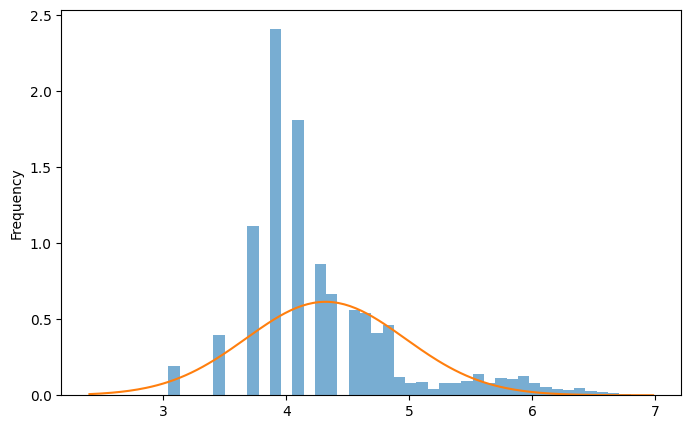

In [16]:
# apply log transformation
target = df["Appliances"]

log_target = np.log1p(target)

print(f'Kurtosis: {kurtosis(log_target)}')

log_target.dropna().plot(
    kind='hist',
    bins=50,
    density=True,
    alpha=0.6,
    figsize=(8,5)
)

mu = log_target.mean()
sigma = log_target.std()

xx = np.linspace(log_target.min(), log_target.max(), 200)
plt.plot(xx, norm.pdf(xx, mu, sigma))
plt.show()
# looks better

# **Time**

In [17]:
# extract basic time features
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['day_of_month'] = df.index.day

# weekend or not
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)

# part of the day
conditions = [
    (df['hour'] >= 6) & (df['hour'] < 12),
    (df['hour'] >= 12) & (df['hour'] < 18),
    (df['hour'] >= 18) & (df['hour'] < 24)
]

choices = [0, 1, 2]  # morning, afternoon, evening

df['time_period'] = np.select(conditions, choices, default=3) # night

In [18]:
# to encode periodic time features
# hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# week
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# day of month
df['day_of_month_sin'] = np.sin(2 * np.pi * df['day_of_month'] / 30)
df['day_of_month_cos'] = np.cos(2 * np.pi * df['day_of_month'] / 30)

# **Train test split**

In [21]:
# define target feature and predictive features and split to train and test
# remove random variables rv1 and rv2
# because XGB and LightGBM can handle overfitting by tuning hyperparameters.

X = df.drop(columns=['Appliances', 'rv1', 'rv2'])
y = np.log1p(df['Appliances'])
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X, y, test_size=0.2, shuffle=False)

In [22]:
# save for later use
joblib.dump(
    y_test_full,
    "y_test_full.joblib"
)

['y_test_full.joblib']

In [23]:
files.download('y_test_full.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
X_train_full.head()

,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,is_weekend,time_period,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,day_of_month_sin,day_of_month_cos
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,...,0,1,-0.965926,-0.258819,0.0,1.0,0.5,0.866025,0.743145,-0.669131
2016-01-11 17:10:00,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,...,0,1,-0.965926,-0.258819,0.0,1.0,0.5,0.866025,0.743145,-0.669131
2016-01-11 17:20:00,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,...,0,1,-0.965926,-0.258819,0.0,1.0,0.5,0.866025,0.743145,-0.669131
2016-01-11 17:30:00,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,...,0,1,-0.965926,-0.258819,0.0,1.0,0.5,0.866025,0.743145,-0.669131
2016-01-11 17:40:00,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,...,0,1,-0.965926,-0.258819,0.0,1.0,0.5,0.866025,0.743145,-0.669131


In [25]:
y_train_full.head()

,Appliances
date,
2016-01-11 17:00:00,4.110874
2016-01-11 17:10:00,4.110874
2016-01-11 17:20:00,3.931826
2016-01-11 17:30:00,3.931826
2016-01-11 17:40:00,4.110874


# **Lights**

In [37]:
# from the histogram, light is a discrete feature
print(df['lights'].unique())

[30 40 50 70 60 10 20  0]


In [39]:
# Use in hafl month-based CV
X_train_folds = []
X_val_folds = []
y_train_folds = []
y_val_folds = []

# training dataset
df_train = X_train_full.copy()
df_train["y"] = y_train_full.values

for train_idx, val_idx in half_month_rolling_splits(df_train):
    X_train, X_val = X_train_full.iloc[train_idx].copy(), X_train_full.iloc[val_idx].copy()
    y_train, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

    # Combine features + target for encoding
    train_df = X_train.assign(y=y_train)

    # Expanding target encoding on training data
    te_series = expanding_target_encoding_mean(train_df, cat_col="lights", target_col="y")
    X_train["lights_te_mean"] = te_series

    # Map encoding to validation (use last value per category from training)
    last_te = te_series.groupby(train_df["lights"]).last()
    global_mean = y_train.mean()
    X_val["lights_te_mean"] = X_val["lights"].map(last_te).fillna(global_mean)

    # Append to lists
    X_train_folds.append(X_train)
    X_val_folds.append(X_val)
    y_train_folds.append(y_train)
    y_val_folds.append(y_val)

In [42]:
# target encoding using median
add_expanding_median_te_to_folds(
    X_train_folds=X_train_folds,
    X_val_folds=X_val_folds,
    y_train_folds=y_train_folds,
    cat_col="lights",
    new_col_name="lights_te_median"
)

# **Time Period**

In [43]:
# Parts of the day
print(df['time_period'].unique()) # morning, afternoon, evening, night

[1 2 3 0]


In [45]:
# target encoding using mean
add_expanding_mean_te_to_folds(
    X_train_folds=X_train_folds,
    X_val_folds=X_val_folds,
    y_train_folds=y_train_folds,
    cat_col="time_period",
    new_col_name="time_period_te_mean"
)

In [46]:
# target encoding using median
add_expanding_median_te_to_folds(
    X_train_folds=X_train_folds,
    X_val_folds=X_val_folds,
    y_train_folds=y_train_folds,
    cat_col="time_period",
    new_col_name="time_period_te_median"
)

# **Hour**

In [47]:
# target encoding using mean
add_expanding_median_te_to_folds(
    X_train_folds=X_train_folds,
    X_val_folds=X_val_folds,
    y_train_folds=y_train_folds,
    cat_col="hour",
    new_col_name="hour_te_median"
)

In [48]:
# target encoding using median
add_expanding_mean_te_to_folds(
    X_train_folds=X_train_folds,
    X_val_folds=X_val_folds,
    y_train_folds=y_train_folds,
    cat_col="hour",
    new_col_name="hour_te_mean"
)

# **Month**

Month's average score calculated above is not greater than 0.3. However, the month may be informative because weather changes between months affect electricity consumption.

In [49]:
# target encoding using mean
add_expanding_mean_te_to_folds(
    X_train_folds=X_train_folds,
    X_val_folds=X_val_folds,
    y_train_folds=y_train_folds,
    cat_col="month",
    new_col_name="month_te_mean"
)

In [50]:
# target encoding using median
add_expanding_median_te_to_folds(
    X_train_folds=X_train_folds,
    X_val_folds=X_val_folds,
    y_train_folds=y_train_folds,
    cat_col="month",
    new_col_name="month_te_median"
)

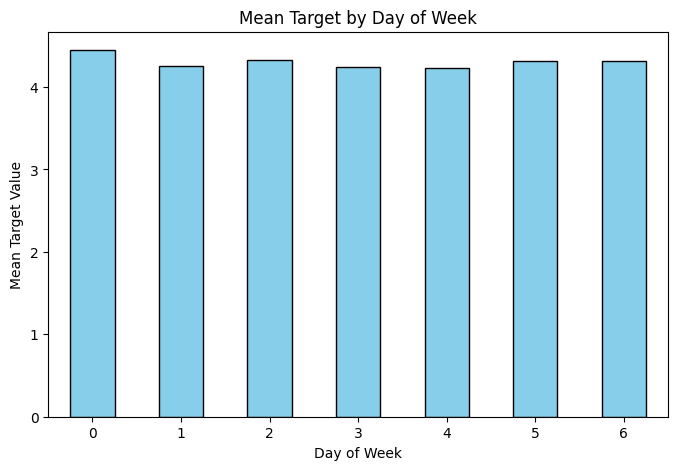

In [51]:
# Check for day of week
# Combine X and y
df_1 = X_train.copy()
df_1["target"] = y_train.values

# Group by day_of_week and compute mean target
target_by_day = df_1.groupby("day_of_week")["target"].mean()

# Plot
plt.figure(figsize=(8,5))
target_by_day.plot(kind="bar", color="skyblue", edgecolor="black")
plt.xlabel("Day of Week")
plt.ylabel("Mean Target Value")
plt.title("Mean Target by Day of Week")
plt.xticks(rotation=0)
plt.show()

# No big difference in mean of target value between days of week
# No need to tranform more

# **Feature Selection**

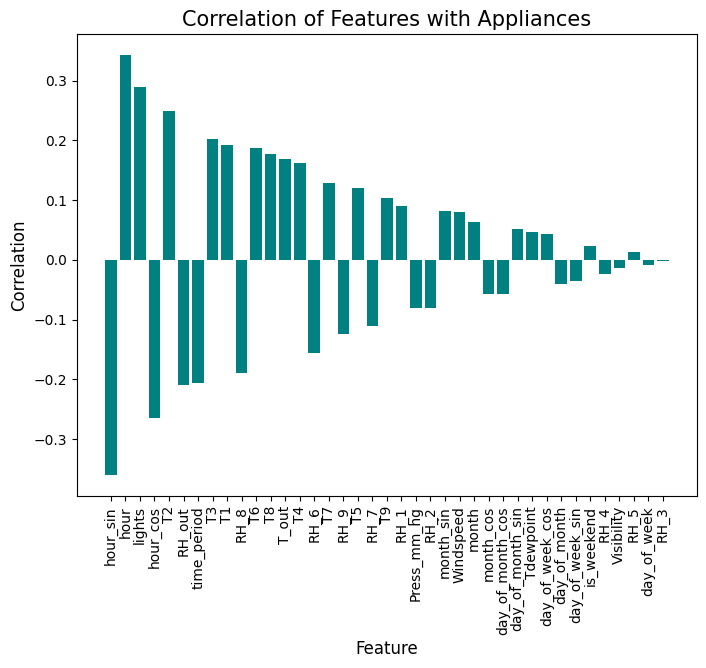

In [26]:
# correlation with target variable
X_train_copy = X_train_full.copy()
X_train_copy["target"] = y_train_full

# Calculate correlation of each feature with target
correlations_init = (
    X_train_copy
    .corr()["target"]
    .drop("target")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

# make a plot
plt.figure(figsize=(8,6))
plt.bar(x=list(correlations_init.index), height=list(correlations_init.values), color='teal')
plt.xticks(rotation=90)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Correlation', fontsize=12)
plt.title('Correlation of Features with Appliances', fontsize=15)
plt.show()

In [27]:
correlations_init.head(10)

,target
hour_sin,-0.360559
hour,0.342418
lights,0.288677
hour_cos,-0.265046
T2,0.249513
RH_out,-0.208845
time_period,-0.205408
T3,0.202113
T1,0.191903
RH_8,-0.189830


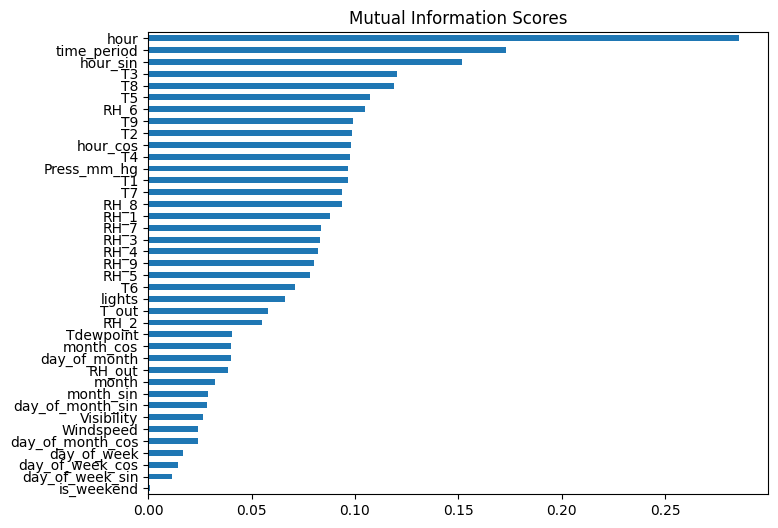

In [30]:
# calculate MI
mi_score_init = mutual_info_regression(X_train_full, y_train_full, random_state=42)

# convert to pandas Series
mi_score_init = pd.Series(mi_score_init, index=X_train_full.columns)

# sort
mi_score_init = mi_score_init.sort_values(ascending=False)

# plot
mi_score_init.plot(kind='barh', figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title("Mutual Information Scores")
plt.show()

In [31]:
# Normalize each score
corr_norm_init = correlations_init.abs() / correlations_init.abs().max()
mi_norm_init = mi_score_init / mi_score_init.max()

# Compute average score
average_score_init = (corr_norm_init + mi_norm_init) / 2
average_score_init = average_score_init.sort_values(ascending=False)

# Convert to dataframe
average_score_df_init = average_score_init.to_frame(name="Score")
print(average_score_df_init)

# based on average score to choose features to transform
# threshold = 0.2

                     Score
hour              0.974844
hour_sin          0.765565
time_period       0.587639
hour_cos          0.538922
T2                0.518726
lights            0.516094
T3                0.491313
T8                0.453012
T1                0.435429
RH_8              0.427146
RH_6              0.400236
T4                0.394734
T6                0.383181
RH_out            0.357549
T5                0.354544
T7                0.343127
T_out             0.334071
T9                0.316330
RH_9              0.312614
RH_7              0.300770
Press_mm_hg       0.282337
RH_1              0.278387
RH_2              0.208702
RH_4              0.175830
month_sin         0.162636
RH_5              0.155370
Windspeed         0.152888
month_cos         0.150331
RH_3              0.147088
month             0.143807
Tdewpoint         0.134968
day_of_month      0.126194
day_of_month_cos  0.122007
day_of_month_sin  0.120794
day_of_week_cos   0.084958
day_of_week_sin   0.068497
V

In [33]:
# Filter features with Score > 0.2 and name starting with "T" - Temperature or "RH_" - Humidity
num_selected_features = [
    feat for feat, score in average_score_df_init["Score"].items()
    if score > 0.2 and (feat.startswith("T") or feat.startswith("RH_"))
]
print(num_selected_features)

['T2', 'T3', 'T8', 'T1', 'RH_8', 'RH_6', 'T4', 'T6', 'RH_out', 'T5', 'T7', 'T_out', 'T9', 'RH_9', 'RH_7', 'RH_1', 'RH_2']


In [34]:
# add Press_mm_hg
num_selected_features.append("Press_mm_hg")

# **Temperature and Humidity in rooms**

In [55]:
# target encoding using mean
bin_and_encode_all_numeric_folds(
    X_train_folds=X_train_folds,
    X_val_folds=X_val_folds,
    y_train_folds=y_train_folds,
    num_cols_to_bin=num_selected_features,
    n_bins=3,
    method="mean"
)

In [56]:
# target encoding using median
bin_and_encode_all_numeric_folds(
    X_train_folds=X_train_folds,
    X_val_folds=X_val_folds,
    y_train_folds=y_train_folds,
    num_cols_to_bin=num_selected_features,
    n_bins=3,
    method="median"
)

In [57]:
# Drop all binned categorical columns (ending with '_bin') after encoding
for i in range(len(X_train_folds)):
    # Identify binned columns in the current fold
    binned_cols = [col for col in X_train_folds[i].columns if col.endswith("_bin")]

    # Drop from both train and val
    X_train_folds[i].drop(columns=binned_cols, inplace=True)
    X_val_folds[i].drop(columns=binned_cols, inplace=True)


In [58]:
# save folds for later use
joblib.dump(
    {
        "X_train_folds": X_train_folds,
        "y_train_folds": y_train_folds,
        "X_val_folds": X_val_folds,
        "y_val_folds": y_val_folds,
    },
    "cv_folds.joblib"
)

['cv_folds.joblib']

In [59]:
files.download('cv_folds.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Correlation and MI score for train set**

In [60]:
# number of features in each fold
print("All features across folds:")
print(X_train_folds[0].columns.tolist())

print("Shape of each fold:")
X_train_folds[0].shape

All features across folds:
['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour', 'day_of_week', 'month', 'day_of_month', 'is_weekend', 'time_period', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'day_of_month_sin', 'day_of_month_cos', 'lights_te_mean', 'lights_te_median', 'time_period_te_mean', 'time_period_te_median', 'hour_te_median', 'hour_te_mean', 'month_te_mean', 'month_te_median', 'T2_bin_te_mean', 'T3_bin_te_mean', 'T8_bin_te_mean', 'T1_bin_te_mean', 'RH_8_bin_te_mean', 'RH_6_bin_te_mean', 'T4_bin_te_mean', 'T6_bin_te_mean', 'RH_out_bin_te_mean', 'T5_bin_te_mean', 'T7_bin_te_mean', 'T_out_bin_te_mean', 'T9_bin_te_mean', 'RH_9_bin_te_mean', 'RH_7_bin_te_mean', 'RH_1_bin_te_mean', 'RH_2_bin_te_mean', 'Press_mm_hg_bin_te_mean', 'T2_bin_te_median', 'T3_bin_te_median', 'T8_bin_t

(1461, 83)

In [61]:
# Compute MI fold by fold
mi_scores_folds = []

for X_train, y_train in zip(X_train_folds, y_train_folds):
    # Make sure all columns are numeric (MI requires numeric input)
    X_train_numeric = X_train.select_dtypes(include=[np.number])

    # Compute MI between each feature and target
    mi = mutual_info_regression(X_train_numeric, y_train, random_state=42)

    # Convert to Series with feature names
    mi_series = pd.Series(mi, index=X_train_numeric.columns)

    mi_scores_folds.append(mi_series)

# Concatenate MI from all folds
mi_df = pd.concat(mi_scores_folds, axis=1)

# Take mean across folds
mi_mean = mi_df.mean(axis=1).sort_values(ascending=False)

print("Top features by MI:")
print(mi_mean.head(10))


Top features by MI:
time_period_te_mean    0.321039
hour                   0.303419
lights_te_mean         0.284576
hour_te_mean           0.278137
hour_te_median         0.220189
T3_bin_te_mean         0.204954
Press_mm_hg            0.197903
T2_bin_te_mean         0.190331
time_period            0.188593
RH_8_bin_te_mean       0.181801
dtype: float64


In [62]:
# Store correlation series for each fold
correlations_folds = []

for X_train, y_train in zip(X_train_folds, y_train_folds):
    # Combine X and y temporarily for correlation
    df_fold = X_train.copy()
    df_fold["target"] = y_train.values

    # Compute correlation of all features with target
    corr = df_fold.corr()["target"].drop("target")

    correlations_folds.append(corr)

# Concatenate all correlations into a DataFrame
corr_df = pd.concat(correlations_folds, axis=1)

# Take mean across folds
mean_corr = corr_df.mean(axis=1)

# Sort by absolute value
mean_corr = mean_corr.sort_values(key=lambda s: s.abs(), ascending=False)

print(mean_corr.head(10))

hour_te_mean             0.491504
hour_te_median           0.458440
lights_te_mean           0.438522
lights_te_median         0.429272
lights                   0.402298
time_period_te_mean      0.400210
time_period_te_median    0.367706
hour                     0.355512
hour_sin                -0.350227
T2_bin_te_mean           0.231880
dtype: float64
